In [3]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt


# Step 1 (Problem Definition)

<b>Problem</b> - A logistic company wants to estimate how manu wants to eleminate  how many liters of fuel a vahicle consume  for a trip  based only on the travel distance

<b>Objective</b> - Predict fuel consumption using the travel distance

Feature (X) - Distance(KM)

Feature (Y) - Fuel Used(L)

# Step 2 (Data Collection)


In [4]:
df = pd.read_csv("../../data/full_fuel_data.csv")

# Step 3 (Data Understanding)


In [5]:
df.head()

,Distance_km,Fuel_Used_Liters
0,10,0.95
1,15,1.32
2,20,1.48
3,25,1.90
4,30,2.55


In [6]:
df.shape

(62, 2)

In [7]:
df.describe()

,Distance_km,Fuel_Used_Liters
count,62.000000,60.000000
mean,152.016129,12.028833
std,85.379863,6.777124
min,10.000000,0.950000
25%,81.250000,6.322500
50%,150.000000,12.020000
75%,223.750000,17.670000
max,300.000000,24.220000


# Step 4 (Data Cleaning)


Identified NULL values and Removed them

In [8]:
df.isnull().sum()

Distance_km         0
Fuel_Used_Liters    2
dtype: int64

In [9]:
df['Distance_km'].isnull().value_counts()

Distance_km
False    62
Name: count, dtype: int64

In [10]:
df['Fuel_Used_Liters'].isnull().value_counts()

Fuel_Used_Liters
False    60
True      2
Name: count, dtype: int64

In [11]:
df =df[~df['Fuel_Used_Liters'].isnull()]

In [12]:
df['Fuel_Used_Liters'].isnull().value_counts()

Fuel_Used_Liters
False    60
Name: count, dtype: int64

Identified Duplicated Values 

In [13]:
df.duplicated().value_counts()

False    57
True      3
Name: count, dtype: int64

In [14]:
df = df.drop_duplicates()

In [15]:
df.duplicated().value_counts()

False    57
Name: count, dtype: int64

In [16]:
import matplotlib.pyplot as plt

In [17]:
x = df['Distance_km']

In [18]:
y = df['Fuel_Used_Liters']

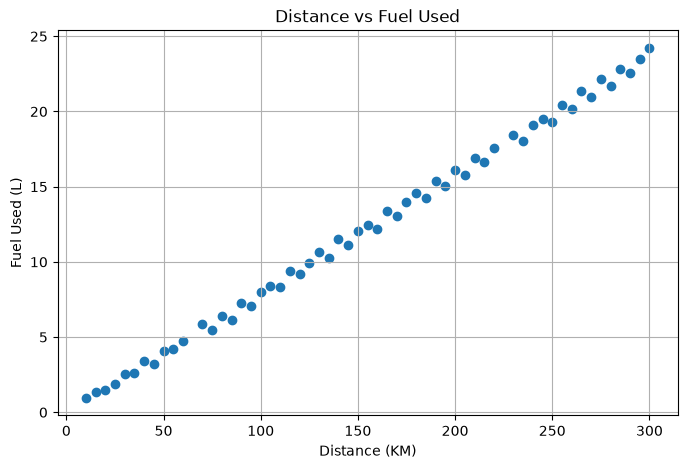

In [19]:
plt.figure(figsize=(8,5))
plt.scatter(x,y)
plt.title("Distance vs Fuel Used")
plt.xlabel("Distance (KM)")
plt.ylabel("Fuel Used (L)")
plt.grid(True)
plt.show()

# Step 5 (Feature Engineering)

In [20]:
x = df[['Distance_km']]

In [21]:
y = df[['Fuel_Used_Liters']]

# Step 6 (Split the data set)

In [22]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# Step 7 (Select ML ALgorithm)

In [23]:
model = LinearRegression()

# Step 8 (Train the model)

In [24]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[0.08]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Distance_km']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-0.01]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


Coefficient -> M

Intercept -> C

Y = MX + C

In [25]:
print("COEF :", model.coef_[0])
print("Intercept :" , model.intercept_)

COEF : [0.07900792]
Intercept : [-0.01026087]


# Step 9 (Evaluate the model)

In [26]:
y_pred = model.predict(x_test)

#### MAE - Mean Absolute Error

In [27]:
mae = mean_absolute_error(y_test,y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 0.23874160803768443


#### R Sqaurred Error

In [28]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test,y_pred)
print("R ^ 2 Score : ", r2)

R ^ 2 Score :  0.9986494066495353


# Step 10 (Visualize the Best Line)

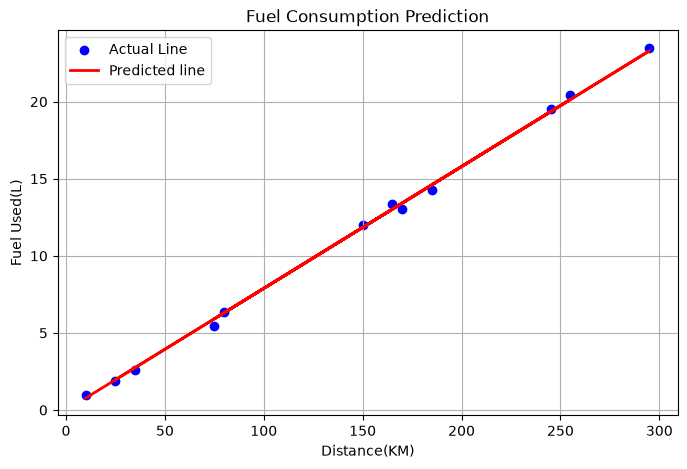

In [29]:
plt.figure(figsize=(8,5))
plt.scatter(x_test,y_test,color='blue',label='Actual Line')
plt.plot(x_test,y_pred,color='red',linewidth="2",label='Predicted line')
plt.title("Fuel Consumption Prediction")
plt.xlabel("Distance(KM)")
plt.ylabel("Fuel Used(L)")
plt.legend()
plt.grid(True)
plt.show()

#### Predict with new Data

In [30]:
distance = 175
prediction = model.predict([[distance]])

print(f"Estimated Fuel Required : {prediction} Liters")

Estimated Fuel Required : [[13.81612494]] Liters


/media/dilan/New Volume/IJSE/4 Sem/ML/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
